# Install Packages

In [1]:
pip install pycaret-ts-alpha

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 468.1/468.1 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.1/303.1 kB 19.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 14.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.2/125.2 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 67.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.4 MB/s eta 0:00:00
  Created wheel for pyod: filename=pyod-1.0.3-py3-none-any.whl size=154726 sha256=75df9edca6dc8ff4877156a78626f7acbd3a9f49336905c81d8757415dd7f82c
  Stored in directory: /root/.cache/pip/wheels/60/1e/04/b42e786399bd7503af674d1ec95d93665b1700309ec3525b65
Successfully built pyod
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.0
    Uninstalling joblib-1.1.0:
      S

In [2]:
from pycaret.classification import *
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sbn
from sklearn.preprocessing import PowerTransformer, LabelEncoder
import warnings
from sklearn.impute import KNNImputer
from collections import Counter
from tqdm import tqdm

# Load Files

In [3]:
#Load file
train = pd.read_csv("../input/titanic/train.csv")
test = pd.read_csv("../input/titanic/test.csv")
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
#Shape
train.shape, test.shape

((891, 12), (418, 11))

In [5]:
#Structure of data
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# EDA Analysis

In [6]:
#Statistics
train.describe().style.background_gradient()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
#Checking unique age values in train set
train.Cabin.unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [8]:
#Checking unique age values in train set
test.Cabin.unique()

array([nan, 'B45', 'E31', 'B57 B59 B63 B66', 'B36', 'A21', 'C78', 'D34',
       'D19', 'A9', 'D15', 'C31', 'C23 C25 C27', 'F G63', 'B61', 'C53',
       'D43', 'C130', 'C132', 'C101', 'C55 C57', 'B71', 'C46', 'C116',
       'F', 'A29', 'G6', 'C6', 'C28', 'C51', 'E46', 'C54', 'C97', 'D22',
       'B10', 'F4', 'E45', 'E52', 'D30', 'B58 B60', 'E34', 'C62 C64',
       'A11', 'B11', 'C80', 'F33', 'C85', 'D37', 'C86', 'D21', 'C89',
       'F E46', 'A34', 'D', 'B26', 'C22 C26', 'B69', 'C32', 'B78',
       'F E57', 'F2', 'A18', 'C106', 'B51 B53 B55', 'D10 D12', 'E60',
       'E50', 'E39 E41', 'B52 B54 B56', 'C39', 'B24', 'D28', 'B41', 'C7',
       'D40', 'D38', 'C105'], dtype=object)

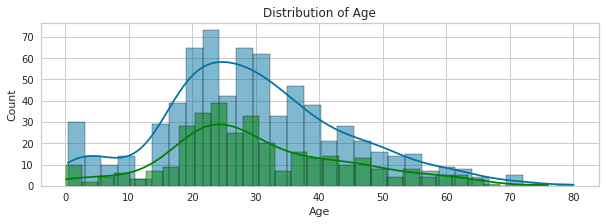

In [9]:
#Distribution of Age
plt.figure(figsize=(10,3))
sbn.histplot(data=train, x='Age', kde=True, bins=30)
sbn.histplot(data=test, x='Age', kde=True, color='green', bins=30)
plt.title("Distribution of Age")
plt.show()

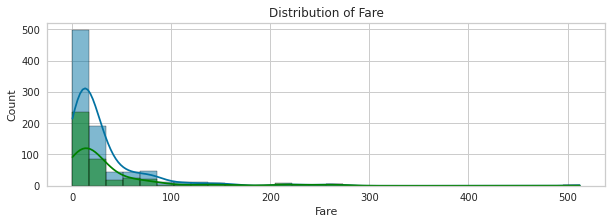

In [10]:
#Distribution of Fare
plt.figure(figsize=(10,3))
sbn.histplot(data=train, x='Fare', kde=True, bins=30)
sbn.histplot(data=test, x='Fare', kde=True, color='green', bins=30)
plt.title("Distribution of Fare")
plt.show()

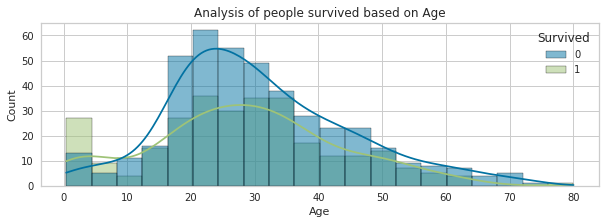

In [11]:
#Analysis of people survived based on Age
plt.figure(figsize=(10,3))
sbn.histplot(data=train, x='Age', kde=True, hue='Survived')
plt.title("Analysis of people survived based on Age")
plt.show()

Most of them over age 10 were dead.

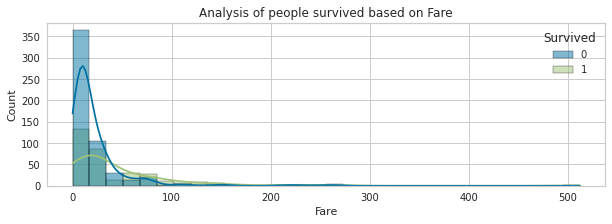

In [12]:
#Analysis of people survived based on Fare
plt.figure(figsize=(10,3))
sbn.histplot(data=train, x='Fare', kde=True, hue='Survived', bins=30)
plt.title("Analysis of people survived based on Fare")
plt.show()

Most of those who gave less than 50 bugs were dead.

We need to normalize the Fair column

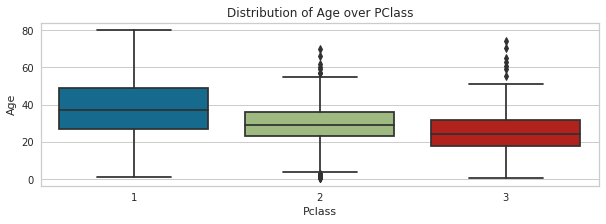

In [13]:
#Distribution of Age over PClass
plt.figure(figsize=(10,3))
sbn.boxplot(data=train, x='Pclass', y='Age')
plt.title("Distribution of Age over PClass")
plt.show()

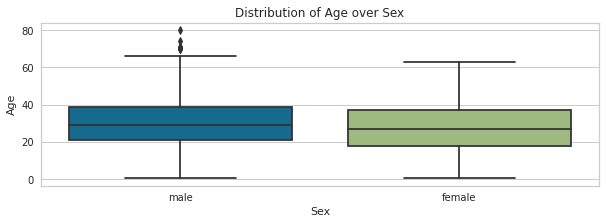

In [14]:
#Distribution of Age over Sex
plt.figure(figsize=(10,3))
sbn.boxplot(data=train, x='Sex', y='Age')
plt.title("Distribution of Age over Sex")
plt.show()

In [15]:
#Survived in Counts
print(train.Survived.value_counts())

0    549
1    342
Name: Survived, dtype: int64


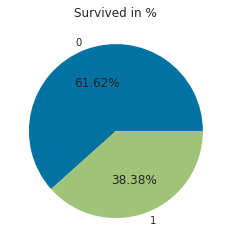

In [16]:
#Survived in %
plt.figure(figsize=(13,4))
plt.pie(x=train.Survived.value_counts(), labels=train.Survived.unique(), autopct='%.2f%%')
plt.title("Survived in %")
plt.show()

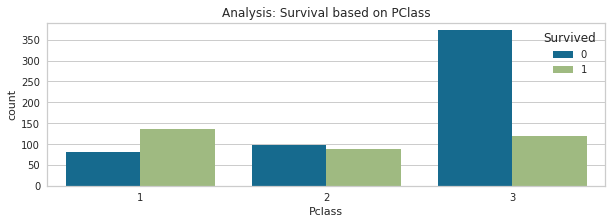

In [17]:
#Analysis Survival based on PClass
plt.figure(figsize=(10,3))
sbn.countplot(data=train, x='Pclass', hue='Survived')
plt.title("Analysis: Survival based on PClass")
plt.show()

In Pclass 3 most of them were dead

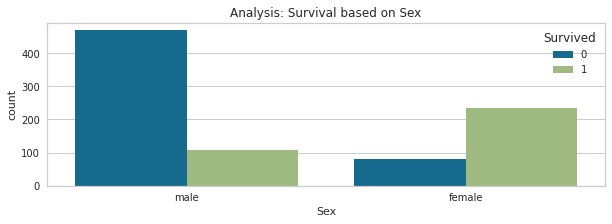

In [18]:
#Analysis Survival based on Sex
plt.figure(figsize=(10,3))
sbn.countplot(data=train, x='Sex', hue='Survived')
plt.title("Analysis: Survival based on Sex")
plt.show()

More males are lost than females.

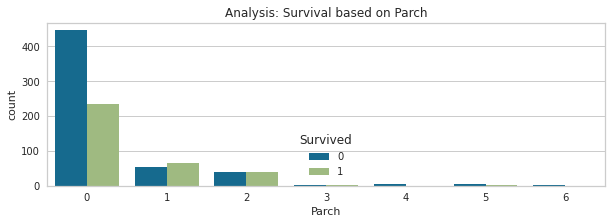

In [19]:
#Analysis Survival based on Parch
plt.figure(figsize=(10,3))
sbn.countplot(data=train, x='Parch', hue='Survived')
plt.title("Analysis: Survival based on Parch")
plt.show()

Most of them were dead in all Parches

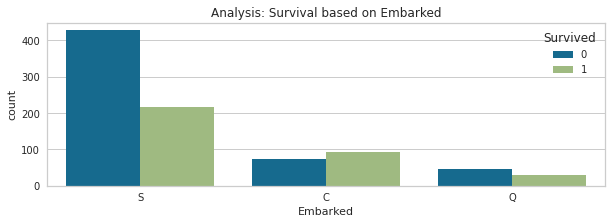

In [20]:
#Analysis Survival based on Embarked
plt.figure(figsize=(10,3))
sbn.countplot(data=train, x='Embarked', hue='Survived')
plt.title("Analysis: Survival based on Embarked")
plt.show()

In Embarked S, Q most of them were dead

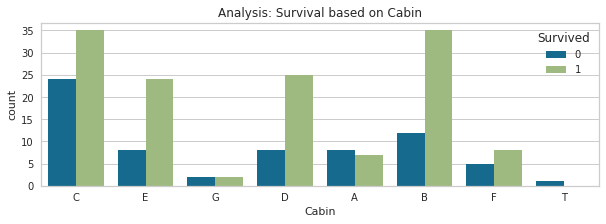

In [21]:
#Analysis Survival based on Cabin
combine_data = [train, test]
for data in combine_data:
    Cabin=[]
    for val in data['Cabin'].values:
        if str(val)=='nan':
            Cabin.append(np.nan)
        else:
            Cabin.append(val[0])
    data['Cabin']=Cabin
plt.figure(figsize=(10,3))
sbn.countplot(data=train, x='Cabin', hue='Survived')
plt.title("Analysis: Survival based on Cabin")
plt.show()  

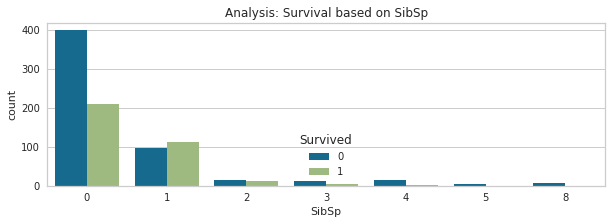

In [22]:
#Analysis Survival based on SibSp
plt.figure(figsize=(10,3))
sbn.countplot(data=train, x='SibSp', hue='Survived')
plt.title("Analysis: Survival based on SibSp")
plt.show()

Most of them were dead in all SibSp

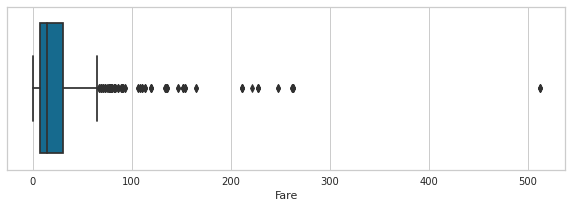

In [23]:
#Checking Outliers 
plt.figure(figsize=(10,3))
sbn.boxplot(data=train, x='Fare')
plt.show()

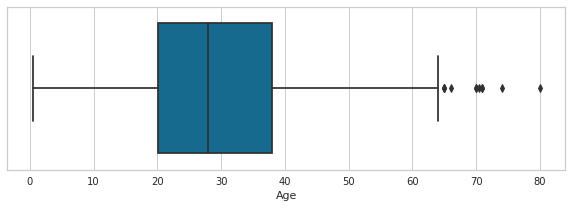

In [24]:
plt.figure(figsize=(10,3))
sbn.boxplot(data=train, x='Age')
plt.show()

<Figure size 720x216 with 0 Axes>

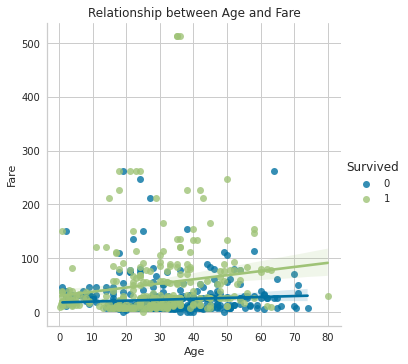

In [25]:
#Relationship between Age and Fare
plt.figure(figsize=(10,3))
sbn.lmplot(data=train, x='Age', y='Fare', hue='Survived')
plt.title("Relationship between Age and Fare")
plt.show()

In [26]:
#Checking Missing Values in train data
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [27]:
#Checking Missing Values in test data
test.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

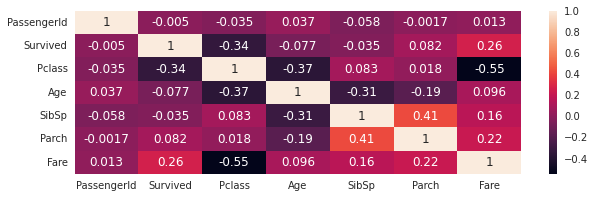

In [28]:
#Checking Correlation Analysis
plt.figure(figsize=(10,3))
sbn.heatmap(train.corr(), annot=True)
plt.show()

In [29]:
#Checking inconsistency in Categorical data
data_combine=[train, test]
for data in data_combine:
    data['Pclass']=data['Pclass'].map({1:'Upper', 2:'Middle', 3:'Lower'})
columns=['Sex', 'Embarked', 'Cabin', 'Pclass']
values = ['train data', 'test data']
for value, data in zip(values, data_combine):
    print('__________________', value, '__________________')
    for col in columns:
        print(col, " : ", data[col].unique())

__________________ train data __________________
Sex  :  ['male' 'female']
Embarked  :  ['S' 'C' 'Q' nan]
Cabin  :  [nan 'C' 'E' 'G' 'D' 'A' 'B' 'F' 'T']
Pclass  :  ['Lower' 'Upper' 'Middle']
__________________ test data __________________
Sex  :  ['male' 'female']
Embarked  :  ['Q' 'S' 'C']
Cabin  :  [nan 'B' 'E' 'A' 'C' 'D' 'F' 'G']
Pclass  :  ['Lower' 'Middle' 'Upper']


# Data Preparation

In [30]:
#Drop unwanted columns
columns=['PassengerId', 'Name', 'Ticket']
test_data=test.copy(deep=True)
data_combine=[train, test]
for data in data_combine:
    data.drop(columns, axis=1, inplace=True)

In [31]:
#Binning Age and Fare Columns
bins=[-1, 10, 20, 30, 40, 50, 60, 70, 81]
labels=[0, 1, 2, 3, 4, 5, 6, 7]
train['Age']=pd.cut(train['Age'], bins=bins, labels=labels)
test['Age']=pd.cut(test['Age'], bins=bins, labels=labels)
bins=[-1, 50, 100, 150, 200, 250, 300, 350, 400,450,500,550]
labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9,10]
train['Fare']=pd.cut(train['Fare'], bins=bins, labels=labels)
test['Fare']=pd.cut(test['Fare'], bins=bins, labels=labels)

In [32]:
#Handling Missing Values
combine_data = [train, test]
for data in combine_data:
    data['Sex']=data['Sex'].map({'female':0, 'male':1})
for data in combine_data:
    data['Embarked']=data['Embarked'].map({'C':0, 'Q':1, 'S':2})
for data in combine_data:
    data['Cabin']=data['Cabin'].map({'B':1, 'E':4, 'A':0, 'C':2, 'D':3, 'F':5, 'G':6})
for data in combine_data:
    data['Pclass']=data['Pclass'].map({'Upper':2, 'Middle':1, 'Lower':0})    

In [33]:
imputer = KNNImputer(n_neighbors=5).fit(train.drop('Survived', axis=1))
train_impute = pd.DataFrame(imputer.transform(train.drop('Survived', axis=1)))
train_impute.columns= train.drop('Survived', axis=1).columns
test_impute = pd.DataFrame(imputer.transform(test))
train_impute['Survived']=train[['Survived']]
test_impute.columns= train.drop('Survived', axis=1).columns
columns = ['Pclass', 'SibSp', 'Parch', 'Embarked', 'Sex', 'Age', 'Fare', 'Cabin']
for col in columns:
    train_impute[col]=train_impute[col].astype('int')
    test_impute[col]=test_impute[col].astype('int')
train_impute.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Survived
0,0,1,2,1,0,0,5,2,0
1,2,0,3,1,0,1,2,0,1
2,0,0,2,0,0,0,4,2,1
3,2,0,3,1,0,1,2,2,1
4,0,1,3,0,0,0,4,2,0


In [34]:
#Feature and Target
Feature=train_impute.drop(['Survived'], axis=1)
target=train_impute['Survived']

In [35]:
column=['Embarked', 'Age', 'Fare', 'Cabin']
Feature = pd.get_dummies(Feature, columns=column)
test_impute = pd.get_dummies(test_impute, columns=column)
test_impute=test_impute.loc[:, Feature.columns]

In [36]:
Feature.shape, test_impute.shape

((891, 29), (418, 29))

In [37]:
#Checking Noise in the data
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=100, min_samples=50).fit(Feature)
set(dbscan.labels_)

{0}

In [38]:
train = pd.concat([Feature, target], axis=1)

# Model Building and Evaluation

In [39]:
s = setup(data=train,
          session_id=1010,
          target='Survived',
          train_size=0.99,
          fold_strategy='stratifiedkfold',
          fold=10,
          fold_shuffle=True,
          silent=True,
          imputation_type=None,
          normalize=True,
          normalize_method='minmax',
          )

,Description,Value
0,Session id,1010
1,Target,Survived
2,Target type,classification
3,Data shape,"(891, 30)"
4,Train data shape,"(882, 30)"
5,Test data shape,"(9, 30)"
6,Numeric features,29
7,Preprocess,True
8,Imputation type,None
9,Iterative imputation iterations,5


In [40]:
top=compare_models(n_select=5)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8187,0.8723,0.6866,0.8196,0.7423,0.6046,0.6142,0.0620
catboost,CatBoost Classifier,0.8176,0.8710,0.6893,0.8159,0.7418,0.6029,0.6125,0.7580
lightgbm,Light Gradient Boosting Machine,0.8108,0.8595,0.6923,0.7973,0.7357,0.5901,0.5980,0.1450
dt,Decision Tree Classifier,0.8097,0.8129,0.6778,0.8040,0.7281,0.5847,0.5946,0.0160
rf,Random Forest Classifier,0.8096,0.8456,0.6982,0.7877,0.7361,0.5885,0.5945,0.1860
xgboost,Extreme Gradient Boosting,0.8096,0.8554,0.7011,0.7883,0.7371,0.5892,0.5959,0.2630
et,Extra Trees Classifier,0.8085,0.8144,0.6805,0.7998,0.7299,0.5837,0.5923,0.1870
lda,Linear Discriminant Analysis,0.8016,0.8618,0.7188,0.7613,0.7342,0.5767,0.5823,0.0160
ridge,Ridge Classifier,0.7993,0.0000,0.7128,0.7600,0.7302,0.5714,0.5772,0.0140
ada,Ada Boost Classifier,0.7993,0.8551,0.7308,0.7532,0.7358,0.5749,0.5810,0.0670


# Tuning Model

In [41]:
tuned_top = [tune_model(i, fold=10, choose_better=True) for i in top]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.7978,0.8262,0.5588,0.8636,0.6786,0.5407,0.5680
1,0.8090,0.8441,0.6765,0.7931,0.7302,0.5838,0.5882
2,0.7841,0.8184,0.6176,0.7778,0.6885,0.5266,0.5348
3,0.8636,0.8818,0.6765,0.9583,0.7931,0.6959,0.7193
4,0.8068,0.8597,0.6471,0.8148,0.7213,0.5764,0.5854
5,0.8295,0.8755,0.6471,0.8800,0.7458,0.6220,0.6386
6,0.8636,0.8883,0.6765,0.9583,0.7931,0.6959,0.7193
7,0.8523,0.9022,0.7353,0.8621,0.7937,0.6797,0.6849
8,0.8295,0.8815,0.6667,0.8462,0.7458,0.6203,0.6302
9,0.8295,0.8573,0.6061,0.9091,0.7273,0.6104,0.6369


# Ensembling Models

In [42]:
blend = blend_models(tuned_top, fold=10)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.7865,0.8289,0.5000,0.8947,0.6415,0.5063,0.5498
1,0.7640,0.8602,0.6471,0.7097,0.6769,0.4917,0.4930
2,0.8182,0.8374,0.7059,0.8000,0.7500,0.6080,0.6110
3,0.8523,0.9041,0.7353,0.8621,0.7937,0.6797,0.6849
4,0.8409,0.8761,0.6765,0.8846,0.7667,0.6492,0.6627
5,0.8409,0.8690,0.7059,0.8571,0.7742,0.6532,0.6605
6,0.8409,0.9058,0.6176,0.9545,0.7500,0.6410,0.6737
7,0.8068,0.9060,0.7353,0.7576,0.7463,0.5904,0.5905
8,0.8409,0.8766,0.6667,0.8800,0.7586,0.6433,0.6571
9,0.8409,0.8485,0.6364,0.9130,0.7500,0.6387,0.6611


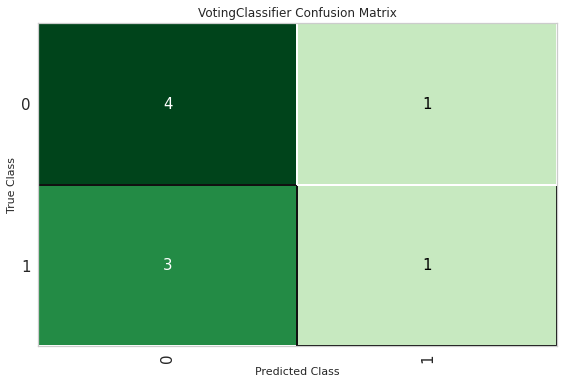

In [43]:
#Confusion Matrix
plot_model(blend, plot='confusion_matrix')

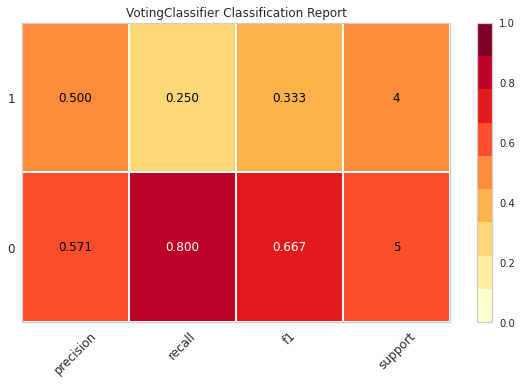

In [44]:
#Classification Report
plot_model(blend, plot='class_report')

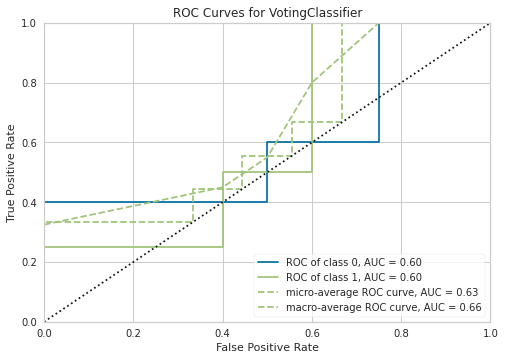

In [45]:
#ROC AUC Curve
plot_model(blend, plot='auc')

# Submissions to Kaggle

In [46]:
#Submit the Prediction to Kaggle
test_data['Survived']=blend.predict(test_impute)
test_data.loc[:,['PassengerId','Survived']].to_csv('Submission.csv', index=False)